In [1]:
import os.path as osp
import random

import xml.etree.ElementTree as ET

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.utils.data as data
import torchvision

import os
import urllib.request

from math import sqrt
from itertools import product
import pandas as pd
# from torch.autograd import Function # 과거에 쓰이던 코드임
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init

In [2]:
# 랜덤값 고정
torch.manual_seed(111)
np.random.seed(111)
random.seed(111)

In [3]:
def make_datapath_list(root):
    img_data_template = osp.join(root, 'JPEGImages', '%s.jpg') # 규칙 설정
    annopath_template = osp.join(root, 'Annotations', '%s.xml')
    tr_ids = osp.join(root, 'ImageSets/Main/train.txt')
    val_ids = osp.join(root, 'ImageSets/Main/val.txt')
    tr_img_list = []
    tr_anno_list = []
    for i in open(tr_ids):
        tr_img_list.append(img_data_template % i.strip())
        tr_anno_list.append(annopath_template % i.strip())
    val_img_list = []
    val_anno_list = []
    for i in open(val_ids):
        val_img_list.append(img_data_template % i.strip())
        val_anno_list.append(annopath_template % i.strip())
    
    return tr_img_list, tr_anno_list, val_img_list, val_anno_list

In [5]:
class Anno_xml2list:
    def __init__(self, classes):
        self.classes = classes
    
    def __call__(self, xml_path, width, height):
        ret = []
        xml = ET.parse(xml_path).getroot()
        class_name_list = self.classes
        for i in xml.iter('object'): # 끝나면 바운딩 박스 하나 종료
            difficult = int(i.find('difficult').text)
            if difficult == 1:
                continue
            bndbox = []
            name = i.find('name').text.lower().strip()
            bbox = i.find('bndbox')
            pts = ['xmin', 'ymin', 'xmax', 'ymax']
            for pt in pts:
                cur_pixel = int(bbox.find(pt).text)-1 # 좌표값은 1부터 시작하므로 연산단위에서 쓰는 0으로 맞추기 위해 계산진행
                if pt == 'xmin' or pt == 'ymin' :
                    cur_pixel /= width
                else:
                    cur_pixel /= height
                bndbox.append(cur_pixel)
            label_index = class_name_list.index(name)
            bndbox.append(label_index)
            ret.append(bndbox)
        return np.array(ret)

In [6]:
from utils import data_a
class Make_dataset_Transform:
    def __init__(self, input_size, color_mean):
        self.base_transform = {
            'train': data_a.Compose([
                data_a.ConvertFromInts(), # int -> float
                data_a.ToAbsoluteCoords(), # 어노테이션 데이터의 규격화
                data_a.PhotometricDistort(), # 랜덤한 색조 변화
                data_a.RandomSampleCrop(), # 이미지 랜덤 샘플화(이미지 증강구조 추가 가능)
                data_a.ToPercentCoords(), # 어노테이션 데이터의 0~1크기의 규격화
                data_a.Resize(input_size), # 크기 변경
                data_a.SubtractMeans(color_mean) # 평균값 차연산
            ]),
            'val': data_a.Compose([
                data_a.ConvertFromInts(),
                data_a.Resize(input_size),
                data_a.SubtractMeans(color_mean)
            ])
        }

    def __call__(self, img, boxes, labels, phase):
        return self.base_transform[phase](img, boxes, labels)

In [ ]:
voc_classes = ['aeroplane', 'bicycle', 'bird', 'boat',
'bottle', 'bus', 'car', 'cat', 'chair',
'cow', 'diningtable', 'dog', 'horse',
'motorbike', 'person', 'pottedplant',
'sheep', 'sofa', 'train', 'tvmonitor']

basepath = './data/VOCdevkit/VOC2012/'
tr_img_list, tr_anno_list, val_img_list, val_anno_list = make_datapath_list(basepath)
color_mean = (104, 117, 123) # BGR 평균
input_size = 300
tr = Make_dataset_Transform(input_size, color_mean)

transform_anno = Anno_xml2list(voc_classes)
idx = 123
img_path = tr_img_list[idx]
img = cv2.imread(img_path)
h,w,c = img.shape
ann_img_tr = transform_anno(tr_anno_list[idx], w, h)
ann_img_tr

array([[ 0.        ,  0.104     ,  0.416     ,  0.54666667, 19.        ],
       [ 0.544     ,  0.478     ,  1.33066667,  0.99733333,  8.        ],
       [ 0.8       ,  0.246     ,  1.15466667,  0.47466667,  4.        ]])

In [9]:
def make_vgg():
    # 그대로 쓸까? 몇몇 레이어만 쓸까? 일부를 새롭게 만들어서 쓸까?
    layers = []
    in_c = 3
    # vgg 모듈 내 합성곱층 맥스풀링층 채널 수 정의
    cfg = [64,64,'M', 128,128,'M',256,256,'MC',512,512,512,'M',512,512,512]
    for i in cfg:
        if i == 'M':
            layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
        elif i == 'MC':
            layers += [nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True)] # ceil모드는 소수점에 의미가 있다고 판단하도록 하는 것임
        else:
            conv2d = nn.Conv2d(in_c, i, kernel_size=3, padding=1)
            layers += [conv2d, nn.ReLU(inplace=True)]
            in_c = i
    pool5 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
    conv6 = nn.Conv2d(512, 1024, kernel_size=3, padding=6, dilation=6) # 팽창 - 수용영역 면적을 넓힘
    conv7 = nn.Conv2d(1024, 1024, kernel_size=1)
    layers += [pool5, conv6, nn.ReLU(inplace=True), conv7, nn.ReLU(inplace=True)]
    return nn.ModuleList(layers)
vgg_m_test = make_vgg()
vgg_m_test

ModuleList(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
  (15): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (16): ReLU(inplace=True)
  (17): Conv2d(512, 512, kernel_siz

In [10]:
def make_extras():
    layers = []
    in_c = 1024
    cfg = [256,512,128,256,128,256,128,256]
    layers += [nn.Conv2d(in_c, cfg[0], kernel_size=(1))]
    layers += [nn.Conv2d(cfg[0], cfg[1], kernel_size=(3), stride=2, padding=1)]
    layers += [nn.Conv2d(cfg[1], cfg[2], kernel_size=(1))]
    layers += [nn.Conv2d(cfg[2], cfg[3], kernel_size=(3), stride=2, padding=1)]
    layers += [nn.Conv2d(cfg[3], cfg[4], kernel_size=(1))]
    layers += [nn.Conv2d(cfg[4], cfg[5], kernel_size=(3))]
    layers += [nn.Conv2d(cfg[5], cfg[6], kernel_size=(1))]
    layers += [nn.Conv2d(cfg[6], cfg[7], kernel_size=(3))]
    return nn.ModuleList(layers)
make_extras()

ModuleList(
  (0): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
  (1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (2): Conv2d(512, 128, kernel_size=(1, 1), stride=(1, 1))
  (3): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (4): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1))
  (5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
  (6): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1))
  (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
)

In [11]:
def make_loc_onf(class_n=21, bbox_aspect_num=[4,6,6,6,4,4]):
    loc_layers, conf_layers = [], []
    
    loc_layers += [nn.Conv2d(512, bbox_aspect_num[0]*4, kernel_size=3, padding=1)]
    conf_layers += [nn.Conv2d(512, bbox_aspect_num[0]*class_n, kernel_size=3, padding=1)]

    loc_layers += [nn.Conv2d(1024, bbox_aspect_num[1]*4, kernel_size=3, padding=1)]
    conf_layers += [nn.Conv2d(1024, bbox_aspect_num[1]*class_n, kernel_size=3, padding=1)]

    loc_layers += [nn.Conv2d(512, bbox_aspect_num[2]*4, kernel_size=3, padding=1)]
    conf_layers += [nn.Conv2d(512, bbox_aspect_num[2]*class_n, kernel_size=3, padding=1)]

    loc_layers += [nn.Conv2d(256, bbox_aspect_num[3]*4, kernel_size=3, padding=1)]
    conf_layers += [nn.Conv2d(256, bbox_aspect_num[3]*class_n, kernel_size=3, padding=1)]

    loc_layers += [nn.Conv2d(256, bbox_aspect_num[4]*4, kernel_size=3, padding=1)]
    conf_layers += [nn.Conv2d(256, bbox_aspect_num[4]*class_n, kernel_size=3, padding=1)]
    
    loc_layers += [nn.Conv2d(256, bbox_aspect_num[5]*4, kernel_size=3, padding=1)]
    conf_layers += [nn.Conv2d(256, bbox_aspect_num[5]*class_n, kernel_size=3, padding=1)]
    
    return nn.ModuleList(loc_layers), nn.ModuleList(conf_layers)

make_loc_onf()

(ModuleList(
   (0): Conv2d(512, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (1): Conv2d(1024, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (2): Conv2d(512, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (3): Conv2d(256, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (4-5): 2 x Conv2d(256, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
 ),
 ModuleList(
   (0): Conv2d(512, 84, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (1): Conv2d(1024, 126, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (2): Conv2d(512, 126, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (3): Conv2d(256, 126, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (4-5): 2 x Conv2d(256, 84, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
 ))

In [12]:
class L2Norm(nn.Module):
    def __init__(self, input_c=512, scale=20): # 4번째 레이어부터 규제 적용함
        super().__init__()
        self.weight = nn.Parameter(torch.Tensor(input_c))
        self.scale = scale
        self.reset_parameter()
        self.eps = 1e-10

    def reset_parameter(self):
        init.constant_(self.weight, self.scale)

    def forward(self, x):
        norm = x.pow(2), sum(dim=1, keepdim=True).sqrt() + self.eps
        x = torch.div(x, norm)
        weights = self.weight.unsqueeze(0).unsqueeze(2).unsqueeze(3).expand_as(x)
        out = weights * x
        return out

In [13]:
ssd_cfg = {
    'num_classes': 21,  # 배경 클래스를 포함한 총 클래스 수
    'input_size': 300,  # 화상의 입력 크기
    'bbox_aspect_num': [4, 6, 6, 6, 4, 4],  # 출력할 Box 화면비의 종류
    'feature_maps': [38, 19, 10, 5, 3, 1],  # 각 source의 화상 크기
    'steps': [8, 16, 32, 64, 100, 300],  # DBOX의 크기를 정한다
    'min_sizes': [30, 60, 111, 162, 213, 264],  # DBOX의 크기를 정한다
    'max_sizes': [60, 111, 162, 213, 264, 315],  # DBOX의 크기를 정한다
    'aspect_ratios': [[2], [2, 3], [2, 3], [2, 3], [2], [2]],
}
class DBox:
    def __init__(self, cfg:dict):
        super().__init__()
        self.img_size = cfg['input_size']
        self.feature_map = cfg['feature_maps']
        self.num_priors = len(cfg['feature_maps'])
        self.steps = cfg['steps']
        self.min_sizes = cfg['min_sizes']
        self.max_sizes = cfg['max_sizes']
        self.aspect_ratios = cfg['aspect_ratios'] # 종횡비

    def make_dbox_list(self):
        mean = []
        for k, f in enumerate(self.feature_map):
            for i, j in product(range(f), repeat=2):
                f_k = self.img_size/self.steps[k]
                cx = (j+0.5)/f_k # 중심 좌표값 찾기
                cy = (i+0.5)/f_k
                
                s_k = self.min_sizes[k]/self.img_size
                mean += [cx, cy, s_k, s_k]
                
                s_k_prime = sqrt(s_k*(self.min_sizes[k]/self.img_size))
                mean += [cx, cy, s_k_prime, s_k_prime]

                for a in self.aspect_ratios[k]: # dbox의 기본 패턴 적용
                    mean += [cx, cy, s_k*sqrt(a), s_k/sqrt(a)]
                    mean += [cx, cy, s_k/sqrt(a), s_k*sqrt(a)]

        output = torch.Tensor(mean).view(-1, 4)
        output.clamp_(max=1, min=0) # 검출 범위가 이미지의 범위를 넘어서지 않도록 작업
        return output
    
dbox = DBox(ssd_cfg)

In [18]:
class SSD(nn.Module):
    def __init__(self, phase, cfg):
        super().__init__()
        self.phase = phase
        self.num_classes = cfg['num_classes']

        self.vgg = make_vgg()
        self.extras = make_extras()
        self.L2Norm = L2Norm()
        self.loc, self.conf = make_loc_onf(cfg['num_classes'], cfg['bbox_aspect_num'])

        dbox=DBox(cfg)
        self.dbox_list = dbox.make_dbox_list()

        if phase == 'inference':
            self.detect = Detect()

ssd_test = SSD(phase='train', cfg=ssd_cfg)
ssd_test

SSD(
  (vgg): ModuleList(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
    (15): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (16): ReLU(i

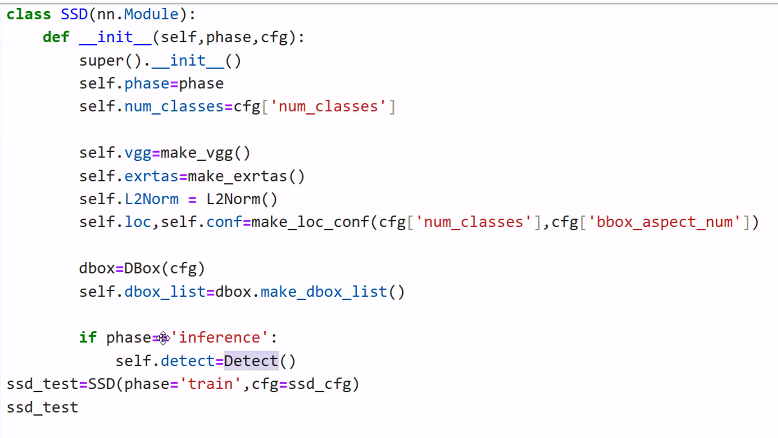

In [15]:
def decode(loc, dbox_list):
    boxes = torch.cat((
        dbox_list[:,:2] + loc[:,:2] *0.1*dbox_list[:,2:],
        dbox_list[:,2:] * torch.exp(loc[:,2:] * 0.2)), dim=1)
    boxes[:,:2] -= boxes[:,:2]/2
    boxes[:,2:] += boxes[:,:2]
    
    return boxes

In [17]:
def nm_suppression(boxes, scores, overlaps=0.45, top_k=200):
    count = 0
    keep = scores.new(scores.size(0)).zero_().long()
    x1 = boxes[:,0]
    y1 = boxes[:,1]
    x2 = boxes[:,2]
    y2 = boxes[:,3]
    area = torch.mul(x2-x1, y2-y1)

    tmp_x1 = boxes.new()
    tmp_y1 = boxes.new()
    tmp_x2 = boxes.new()
    tmp_y2 = boxes.new()
    tmp_w = boxes.new()
    tmp_h = boxes.new()

    v, idx = scores.sort(0)
    idx = idx[-top_k:]

    while idx.numel() > 0:
        i = idx[-1]
        keep[count] = i
        count += 1

        if idx.size(0) == 1:
            break
        idx = idx[:-1]
        torch.index_select(x1, 0, idx, out=tmp_x1)
        torch.index_select(y1, 0, idx, out=tmp_y1)
        torch.index_select(x2, 0, idx, out=tmp_x2)
        torch.index_select(y2, 0, idx, out=tmp_y2)

        tmp_x1 = torch.clamp(tmp_x1, min=x1[i])
        tmp_y1 = torch.clamp(tmp_y1, min=y1[i])
        tmp_x2 = torch.clamp(tmp_x2, min=x2[i])
        tmp_y2 = torch.clamp(tmp_y2, min=y2[i])

        tmp_w.resize_as_(tmp_x2)
        tmp_h.resize_as_(tmp_y2)

        tmp_w = tmp_x2 - tmp_x1
        tmp_h = tmp_y2 - tmp_y1

        tmp_w = torch.clamp(tmp_w, min=0.0)
        tmp_h = torch.clamp(tmp_h, min=0.0)

        inter = tmp_h * tmp_w

        rem_areas = torch.index_select(area, 0, idx)
        union = (rem_areas-inter) + area[i]
        IoU = inter / union
        idx = idx[IoU.le(overlaps)]

In [19]:
class Detect(nn.Module):
    def __init__(self, conf_thresh=0.01, top_k=200, nms_thresh=0.45):
        super().__init__()
        self.softmax = nn.Softmax(dim=1)
        self.conf_thresh = conf_thresh
        self.top_k = top_k
        self.nms_thresh = nms_thresh

    def forward(self, loc_data, conf_data, dbox_list):
        num_batch = loc_data.size(0)
        num_dbox = loc_data.size(1)
        num_classes = loc_data.size(2)

        conf_data = self.softmax(conf_data)
        output = torch.zeros(num_batch, num_classes, self.top_k, 5)
        conf_preds = conf_data.transpose(2,1)

        for i in range(num_batch):
            decoded_boxes = decode(loc_data[i], dbox_list)
            conf_scores = conf_preds[i].clone()

            for cl in range(1, num_classes): # 배경을 제외한 횟수만큼
                c_mask = conf_scores[cl].gt(self.conf_thresh)
                scores = conf_scores[cl][c_mask]
                if scores.nelement() == 0:
                    continue
                l_mask = c_mask.unsqueeze(1).expand_as(decoded_boxes)
                boxes = decoded_boxes[l_mask].view(-1,4)

                idx, count = nm_suppression(boxes, scores, self.nms_thresh, self.top_k)
                output[i,cl,: count] = torch.cat((scores[idx[:count]].unsqueeze(1), boxes[idx[:count]]),1)
        return output

In [ ]:
class SSD(nn.Module):
    def __init__(self, phase, cfg):
        super().__init__()
        self.phase = phase
        self.num_classes = cfg['num_classes']

        self.vgg = make_vgg()
        self.extras = make_extras()
        self.L2Norm = L2Norm()
        self.loc, self.conf = make_loc_onf(cfg['num_classes'], cfg['bbox_aspect_num'])

        dbox=DBox(cfg)
        self.dbox_list = dbox.make_dbox_list()

        if phase == 'inference':
            self.detect = Detect()

    def forward(self, x):
        sources = []
        loc = []
        conf = []

        for k in range(23):
            x = self.vgg[k](x)
        source1 = self.L2Norm(x)
        sources.append(source1)
        for k in range(23, len(self.vgg)):
            x = self.vgg[k](x)
        sources.append(x)
        for k, v in enumerate(self.extras):
            x = F.relu(v(x), inplace=True)
            if k % 2 == 1:
                sources.append(x)
        for (x,l,c) in zip(sources, self.loc, self.conf):
            loc.append(l(x).permute(0,2,3,1).contiguous())
            conf.append(c(x).permute(0,2,3,1).contiguous())
        loc = torch.cat([o.view(o.size(0), -1) for o in loc], 1)
        conf = torch.cat([o.view(o.size(0), -1) for o in conf], 1)
        loc = loc.view(loc.size(0), -1, 4)
        conf = conf.view(conf.size(0), -1, self.num_classes)

        output = (loc, conf, self.dbox_list)
        
        if self.phase == 'inference':
            return self.detect(output[0], output[1], output[2])
        else:
            return output

In [ ]:
class MultiBoxLoss(nn.Module):
    def __init__(self, jaccard_thresh=0.5, neg_os=3):
        super().__init__()
        self.jaccard_thresh = jaccard_thresh
        self.neg_os = neg_os

    def forward(self, py, ty):
        loc_data, conf_data, dbox_list = py
        n_batch = loc_data.size(0) # 배치사이즈
        n_dbox = loc_data.size(1) # dbox 개수(8700개였나)
        n_classes = conf_data.size(2) # 클래스 개수(사실 cfg에도 있음)
        
        conf_t_label = torch.LongTensor(n_batch, n_dbox)
        loc_t = torch.Tensor(n_batch, n_dbox, 4)

        for idx in range(n_batch):
            truths = ty[idx][:,:-1]
            labels = ty[idx][:,-1]
            dbox = dbox_list
            variance = [0.1, 0.2]
            match(self, self.jaccard_thresh, truths, dbox, variance, labels, loc_t, conf_t_label, idx)
        # 위치 손실, 클래스 손실 파악
        # 데이터 안에 있는 객체의 위치 클래스 일치성을 통합하여 로스값 계산


# 기구축된 모듈 활용 모델 학습

In [1]:
import os.path as osp
import random
import time

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

torch.manual_seed(1111)
np.random.seed(1111)
random.seed(1111)

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# 데이티 로드
from utils.ssd_model import make_datapath_list, Anno_xml2list, DataTransform, VOCDataset, od_collate_fn
basepath = './data/VOCdevkit/VOC2012/'
tr_img_list, tr_anno_list, val_img_list, val_anno_list = make_datapath_list(basepath)
voc_classes = ['aeroplane', 'bicycle', 'bird', 'boat',
'bottle', 'bus', 'car', 'cat', 'chair',
'cow', 'diningtable', 'dog', 'horse',
'motorbike', 'person', 'pottedplant',
'sheep', 'sofa', 'train', 'tvmonitor']
color_mean = (104, 117, 123)
input_size = 300
tr_ds = VOCDataset(tr_img_list, tr_anno_list, phase='train', 
           transform=DataTransform(input_size, color_mean), 
           transform_anno=Anno_xml2list(voc_classes))
val_ds = VOCDataset(tr_img_list, tr_anno_list, phase='val', 
           transform=DataTransform(input_size, color_mean), 
           transform_anno=Anno_xml2list(voc_classes))

In [4]:
BATCH_SIZE = 32
tr_ds_loader = data.DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=od_collate_fn)
val_ds_loader = data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=od_collate_fn)
dataLoader_dict = {'train':tr_ds_loader, 'val':val_ds_loader}

In [6]:
# 모델 구축
from utils.ssd_model import SSD

In [ ]:
ssd_cfg = {
    'num_classes': 21,  # 배경 클래스를 포함한 총 클래스 수
    'input_size': 300,  # 화상의 입력 크기
    'bbox_aspect_num': [4, 6, 6, 6, 4, 4],  # 출력할 Box 화면비의 종류
    'feature_maps': [38, 19, 10, 5, 3, 1],  # 각 source의 화상 크기
    'steps': [8, 16, 32, 64, 100, 300],  # DBOX의 크기를 정한다
    'min_sizes': [30, 60, 111, 162, 213, 264],  # DBOX의 크기를 정한다
    'max_sizes': [60, 111, 162, 213, 264, 315],  # DBOX의 크기를 정한다
    'aspect_ratios': [[2], [2, 3], [2, 3], [2, 3], [2], [2]],
}
m = SSD(phase='train', cfg=ssd_cfg)
vgg_weights = torch.load('weights/vgg16_reducedfc.pth')
m.vgg.load_state_dict(vgg_weights) # 가중치를 기학습된 가중치값으로 로드
def weights_init(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight.data)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)

m.extras.apply(weights_init)
m.loc.apply(weights_init)
m.conf.apply(weights_init)

ModuleList(
  (0): Conv2d(512, 84, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): Conv2d(1024, 126, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (2): Conv2d(512, 126, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): Conv2d(256, 126, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4-5): 2 x Conv2d(256, 84, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

In [9]:
# 로스 계산
from utils.ssd_model import MultiBoxLoss
criterion = MultiBoxLoss(jaccard_thresh=0.5, neg_pos=3, device=DEVICE)
opt = optim.SGD(m.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4)

In [ ]:
# 학습
def train_m(m, dataLoader_dict, criterion, opt, n_epochs, *, 
            val_every=1, save_dir='weights', save_every=10, clip_grad_norm=2.0, verbose_iter=10):
    m.to(DEVICE)
    os.makedirs(save_dir, exist_ok=True)